In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('restaurant_reviews_50k.csv')

In [3]:
df.head()

,review_text,label
0,Avoid this restaurant at all costs. The manage...,0
1,Running the math on value here: My visit was p...,2
2,I came in for a quick lunch and left two hours...,4
3,The manager was aggressive. Never returning. A...,0
4,Visited on my third visit. The menu described ...,1


In [4]:
df.label.value_counts()

,count
label,
0,10000
2,10000
4,10000
1,10000
3,10000


In [5]:
max(df.review_text)

'Zero stars. Filthy nad hostile. A classic American restaurant that tries hard.'

In [6]:
df.review_text.loc[df.review_text.str.len().idxmax()]

"Visited on a Saturday afternoon. The plating was content-worthy but There are restaurants you visit, and restaurants that visit you — this is the latter. The food across every course had me closing my eyes involuntarily — the kind of food that demands your full attention. Every interaction felt like a conversation, not a transaction. Sitting there felt like being let in on a secret the city hadn't quite discovered yet. The French Bistro influence here isn't decoration — it's woven into every technique and ingredient choice. We marked this for our next celebration before we'd even finished dessert. Our server described each dish like a proud author reading their own chapter. The dessert alone was worth the visit. I would drive two hours for this meal. I have driven two hours for this meal. This is a Mediterranean-inspired spot."

In [7]:
df.review_text.loc[df.review_text.str.len().idxmin()]

'It was fine.'

In [8]:
df[df.review_text.notna()==False]

,review_text,label


In [9]:
df[df.label.notna()==False]

,review_text,label


In [10]:
from pandas._libs.tslibs import timestamps
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review_text'].tolist(),
    df['label'].tolist(),
    test_size=0.15,
    stratify=df['label'].tolist(),
    random_state=42
)

In [11]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
def get_embeddings(texts, batch_size=32):
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        show_progress_bar=True
    )
    return embeddings

In [13]:
X_train = get_embeddings(train_texts)
X_test = get_embeddings(test_texts)

y_train = np.array(train_labels)
y_test = np.array(test_labels)

Batches:   0%|          | 0/1329 [00:00<?, ?it/s]

Batches:   0%|          | 0/235 [00:00<?, ?it/s]

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=5
)

clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:28:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, ...)

In [16]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9929333333333333
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1500
           1       0.99      0.99      0.99      1500
           2       1.00      0.99      0.99      1500
           3       0.99      0.99      0.99      1500
           4       0.99      0.99      0.99      1500

    accuracy                           0.99      7500
   macro avg       0.99      0.99      0.99      7500
weighted avg       0.99      0.99      0.99      7500



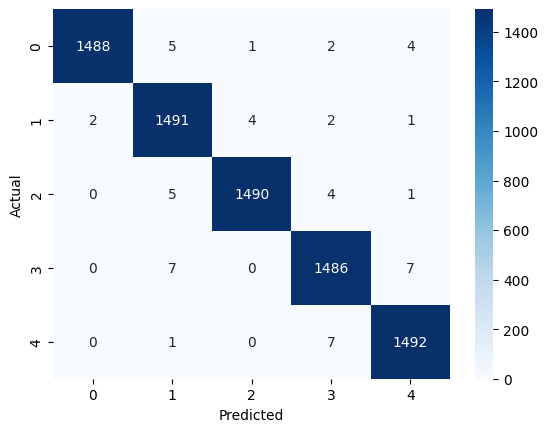

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
import joblib

# Save ML components
joblib.dump(clf, "ml_classifier.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save embedding model
model.save("sentence_transformer_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
from sentence_transformers import SentenceTransformer
import joblib

# Load everything
model = SentenceTransformer("sentence_transformer_model")
clf = joblib.load("ml_classifier.pkl")
scaler = joblib.load("scaler.pkl")

def predict_sentiment(text):
    embedding = model.encode([text])
    embedding = scaler.transform(embedding)
    pred = clf.predict(embedding)[0]
    return pred

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [20]:
label_map = {
    0: "Very Negative",
    1: "Negative",
    2: "Neutral",
    3: "Positive",
    4: "Very Positive"
}

def predict_with_label(text):
    pred = predict_sentiment(text)
    return label_map[pred]

In [22]:
predict_with_label("food was ok but service was terrible")

'Neutral'

In [23]:
predict_with_label("absolutely loved the vibe and food")

'Positive'

In [24]:

predict_with_label("not worth the price at all")

'Negative'

In [26]:
from google.colab import files
files.download('sentence_transformer_model')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>